In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns

In [119]:
df = pd.read_csv("fraud_detection_transactions.csv")
duplicates = df.duplicated().sum()
print("The number of duplicated transaction excluding \nthe first occurence of the transaction:",duplicates)


The number of duplicated transaction excluding 
the first occurence of the transaction: 4


In [122]:
# Transaction above threshold
threshold = 100000
high_value_trxn=df[df["TransactionAmount"]>threshold]
print(high_value_trxn)

    TransactionID AccountID      TransactionDate  TransactionAmount  \
11        TXN0143   ACC1003  2026-07-17 20:11:00             107377   
12        TXN0020   ACC1005  2026-07-24 18:36:00             111993   
23        TXN0068   ACC1014  2026-07-16 17:48:00             114332   
52        TXN0134   ACC1002  2026-07-14 00:29:00             106267   
53        TXN0017   ACC1010  2026-07-13 21:41:00             117839   
73        TXN0040   ACC1011  2026-07-09 02:49:00             116768   
81        TXN0034   ACC1001  2026-07-11 04:40:00             107912   
91        TXN0050   ACC1017  2026-07-18 19:20:00             116162   
135       TXN0130   ACC1002  2026-07-22 02:17:00             113656   
139       TXN0053   ACC1005  2026-07-23 06:04:00             111069   

    TransactionCategory PaymentMethod    Location  
11               Travel   Net Banking  Chandigarh  
12                Bills           UPI       Delhi  
23             Shopping           UPI  Chandigarh  
52        

    TransactionID AccountID     TransactionDate  TransactionAmount  \
53        TXN0017   ACC1010 2026-07-13 21:41:00             117839   
73        TXN0040   ACC1011 2026-07-09 02:49:00             116768   
91        TXN0050   ACC1017 2026-07-18 19:20:00             116162   
23        TXN0068   ACC1014 2026-07-16 17:48:00             114332   
135       TXN0130   ACC1002 2026-07-22 02:17:00             113656   
12        TXN0020   ACC1005 2026-07-24 18:36:00             111993   
139       TXN0053   ACC1005 2026-07-23 06:04:00             111069   
81        TXN0034   ACC1001 2026-07-11 04:40:00             107912   
11        TXN0143   ACC1003 2026-07-17 20:11:00             107377   
52        TXN0134   ACC1002 2026-07-14 00:29:00             106267   

    TransactionCategory PaymentMethod    Location  
53                 Food          Card    Gurugram  
73           Healthcare           UPI       Delhi  
91             Transfer          Card       Hisar  
23             Shoppi

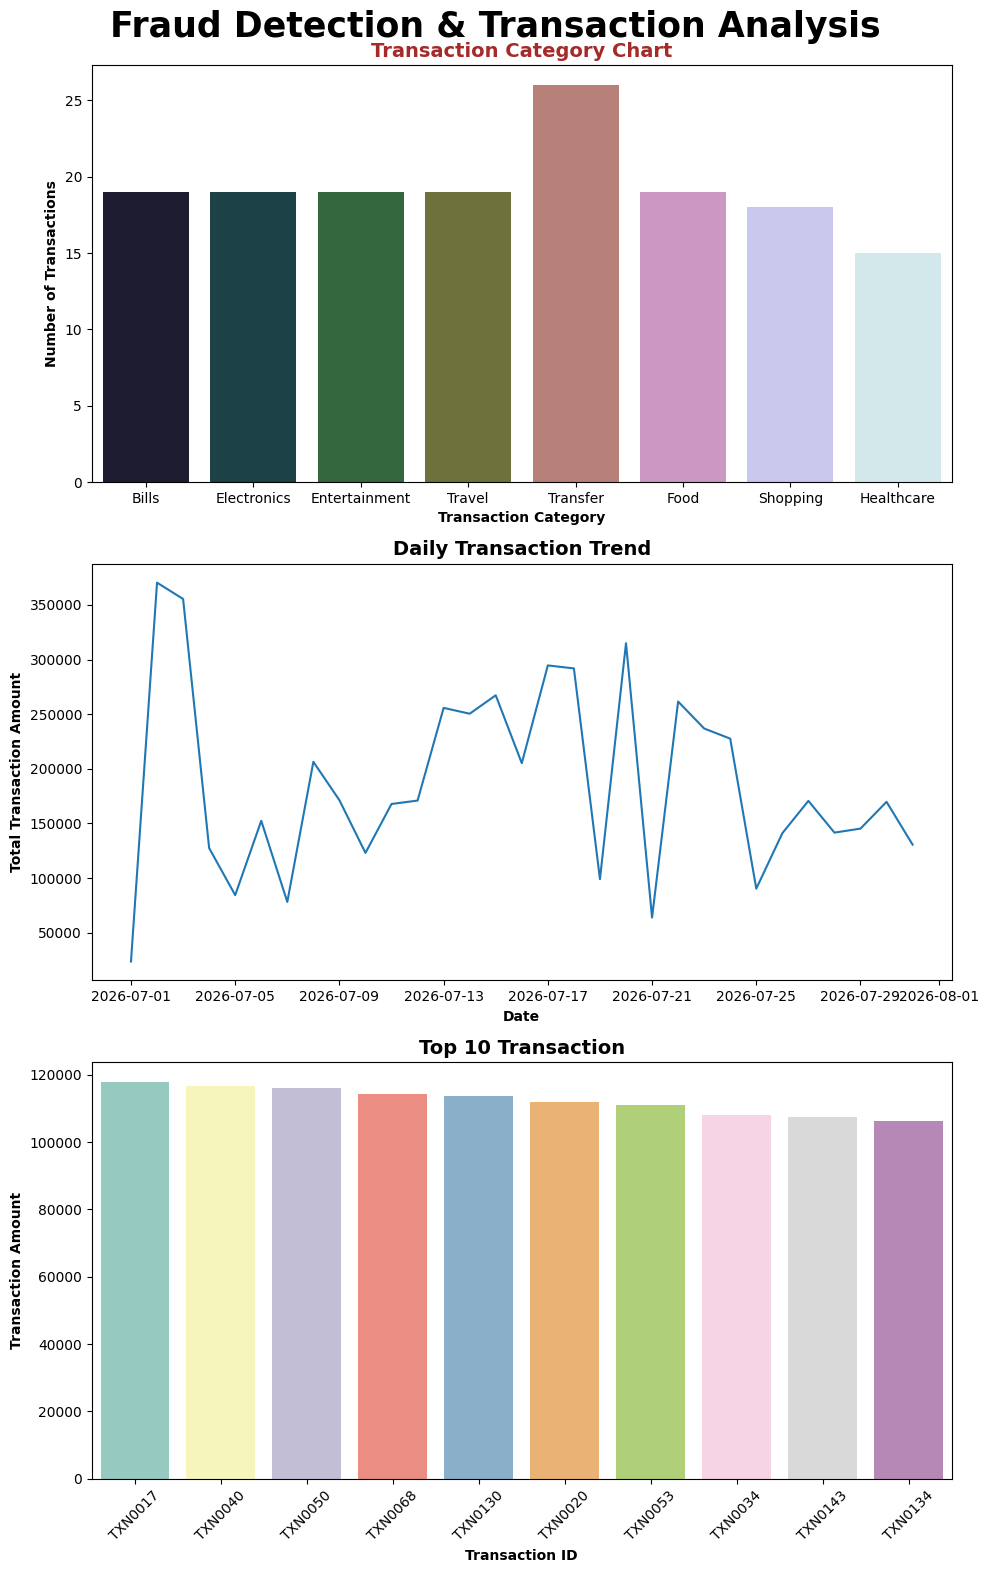

In [123]:
# Visualisation
# Category chart
fig,axes = plt.subplots(3,1,figsize=(10,16))
fig.suptitle("Fraud Detection & Transaction Analysis",fontweight="bold",color = "black",fontsize=25)
sns.countplot(data=df,x ="TransactionCategory",ax = axes[0],palette = "cubehelix",hue ="TransactionCategory")
axes[0].set_title("Transaction Category Chart",fontweight = 'bold',fontsize = 14,color ="brown")
axes[0].set_xlabel("Transaction Category",fontweight = 'bold')
axes[0].set_ylabel("Number of Transactions",fontweight = 'bold')

plt.xticks(rotation=45)

# Daily Transactions Trend
df["TransactionDate"]=pd.to_datetime(df["TransactionDate"])
daily_transactions = df.groupby(df["TransactionDate"].dt.date)["TransactionAmount"].sum()
axes[1].plot(
    daily_transactions.index,
    daily_transactions.values
)

axes[1].set_xlabel("Date",fontweight='bold') 
axes[1].set_ylabel("Total Transaction Amount",fontweight='bold')
axes[1].set_title("Daily Transaction Trend",fontsize=14,fontweight='bold')

plt.xticks(rotation=45)

top10 = df.nlargest(10,"TransactionAmount")
print(top10)
sns.barplot(data=top10,x="TransactionID",
    y="TransactionAmount",palette="Set3",ax=axes[2],hue="TransactionID")
axes[2].set_title("Top 10 Transaction",fontweight = 'bold',fontsize = 14)
axes[2].set_xlabel("Transaction ID",fontweight = 'bold')
axes[2].set_ylabel("Transaction Amount",fontweight='bold')
plt.tight_layout()